# Deep Learning Assignment 6 VAE

## Anomaly Detection in Brain MRI using Variational Autoencoder (VAE)
## Team 65
## Shishir Kumar Reddy Ambala CS23B2043
## Sohan Kumar Anumalasetty CS23B1004


---
## Section 1 — Imports & Device Configuration

We import all necessary libraries upfront for clarity. PyTorch is used for the VAE; OpenCV handles image I/O and morphological operations; `scipy` provides connected-component labelling for ROI clean-up.

Using a GPU (`cuda`) will significantly speed up training. The notebook falls back to CPU automatically.


In [14]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import cv2
from PIL import Image
from scipy.ndimage import label as scipy_label

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA

# ── device ────────────────────────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cpu


---
## Section 2 — Dataset Loading & Exploration
- If `mask.sum() == 0` → **Normal** (no tumour visible)
- If `mask.sum() > 0`  → **Abnormal** (tumour present)

In [ ]:
data_path = "/kaggle/input/datasets/mateuszbuda/lgg-mri-segmentation/lgg-mri-segmentation/kaggle_3m"

all_images  = sorted(glob.glob(data_path + "/**/*.tif", recursive=True))
image_paths = [p for p in all_images if "_mask" not in p]
mask_paths  = [p for p in all_images if "_mask"     in p]

print(f"Total images : {len(image_paths)}")
print(f"Total masks  : {len(mask_paths)}")


Total images : 3929
Total masks  : 3929


In [ ]:
# split normal / abnormal
normal_images   = []
abnormal_images = []

for img_path in image_paths:
    mask_path = img_path.replace(".tif", "_mask.tif")
    if os.path.exists(mask_path):
        mask = cv2.imread(mask_path, 0)
        if np.sum(mask) == 0:
            normal_images.append(img_path)
        else:
            abnormal_images.append(img_path)

print(f"Normal   (no tumour) : {len(normal_images)}")
print(f"Abnormal (tumour)    : {len(abnormal_images)}")


Normal   (no tumour) : 2556
Abnormal (tumour)    : 1373


### Visualise Sample Images

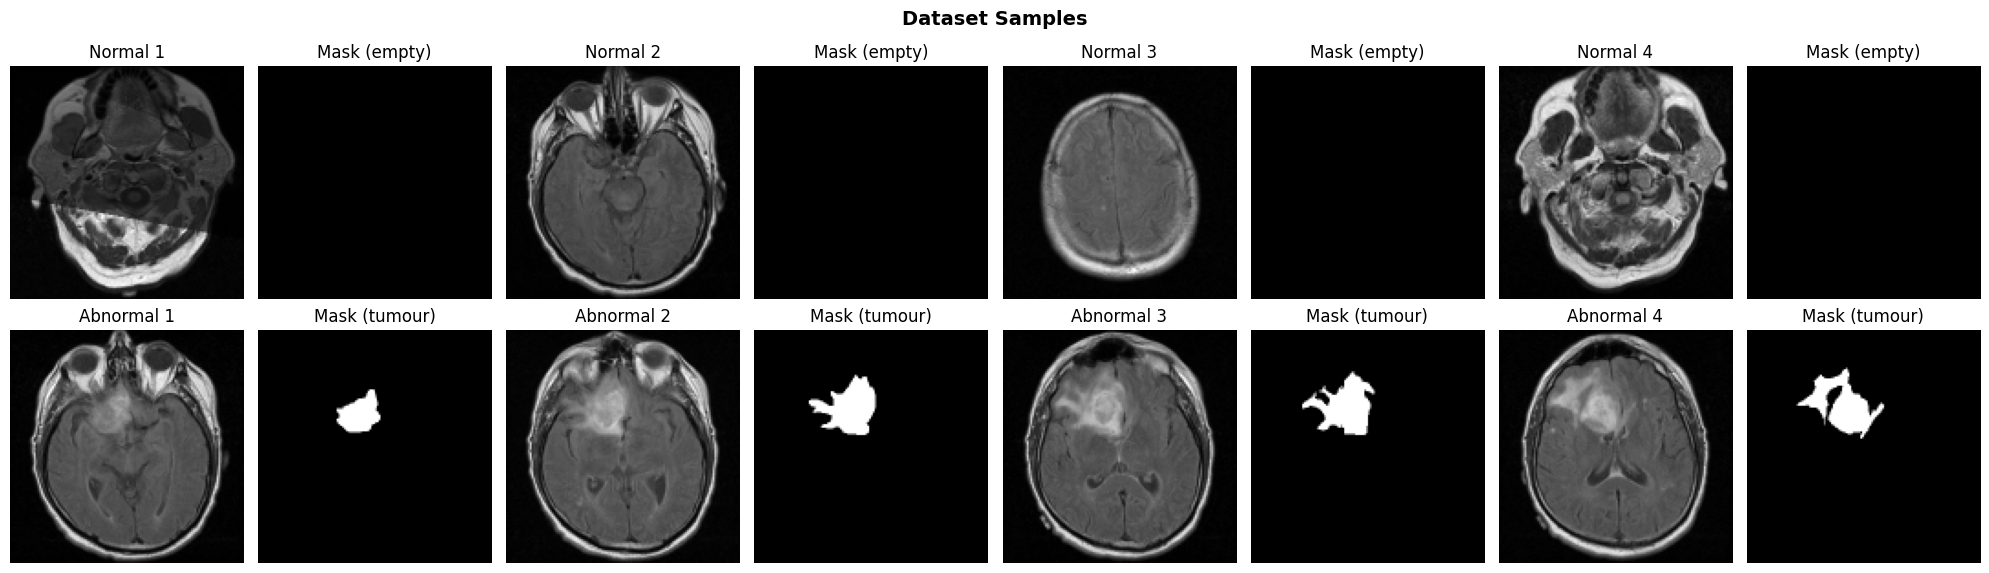

In [17]:
def show_samples(normal_paths, abnormal_paths, n=4, img_size=128):
    """Display n normal and n abnormal slices with their masks."""
    fig, axes = plt.subplots(2, n * 2, figsize=(n * 5, 6))
    fig.suptitle("Dataset Samples", fontsize=14, fontweight="bold")

    for col in range(n):
        # normal
        img  = cv2.resize(cv2.imread(normal_paths[col], 0), (img_size, img_size))
        mask = cv2.resize(cv2.imread(normal_paths[col].replace(".tif", "_mask.tif"), 0),
                          (img_size, img_size))
        axes[0, col * 2].imshow(img, cmap="gray"); axes[0, col * 2].set_title(f"Normal {col+1}")
        axes[0, col * 2 + 1].imshow(mask, cmap="gray"); axes[0, col * 2 + 1].set_title("Mask (empty)")

        # abnormal
        img  = cv2.resize(cv2.imread(abnormal_paths[col], 0), (img_size, img_size))
        mask = cv2.resize(cv2.imread(abnormal_paths[col].replace(".tif", "_mask.tif"), 0),
                          (img_size, img_size))
        axes[1, col * 2].imshow(img, cmap="gray"); axes[1, col * 2].set_title(f"Abnormal {col+1}")
        axes[1, col * 2 + 1].imshow(mask, cmap="gray"); axes[1, col * 2 + 1].set_title("Mask (tumour)")

    for ax in axes.flat:
        ax.axis("off")
    plt.tight_layout()
    plt.show()

show_samples(normal_images, abnormal_images, n=4)


## Section 3 — Data Splitting & PyTorch Datasets

In [ ]:
# train val test split
train_imgs, val_imgs = train_test_split(normal_images, test_size=0.1, random_state=42)
test_imgs = abnormal_images[:200]

print(f"Train : {len(train_imgs):>5} normal slices")
print(f"Val   : {len(val_imgs):>5} normal slices")
print(f"Test  : {len(test_imgs):>5} abnormal slices")


Train :  2300 normal slices
Val   :   256 normal slices
Test  :   200 abnormal slices


### MRI Dataset Class

In [19]:
class MRIDataset(Dataset):
    """Grayscale MRI slice dataset. Returns (1, H, W) float32 tensors in [0, 1]."""

    def __init__(self, image_paths, size=128):
        self.image_paths = image_paths
        self.size = size

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = cv2.imread(self.image_paths[idx], 0)          # grayscale
        img = cv2.resize(img, (self.size, self.size))
        img = img / 255.0                                    # normalise → [0, 1]
        img = np.expand_dims(img, 0)                         # (1, H, W)
        return torch.tensor(img, dtype=torch.float32)


In [ ]:
# DataLoaders
IMG_SIZE   = 128
BATCH_SIZE = 32

train_dataset = MRIDataset(train_imgs, size=IMG_SIZE)
val_dataset   = MRIDataset(val_imgs,   size=IMG_SIZE)
test_dataset  = MRIDataset(test_imgs,  size=IMG_SIZE)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=1,          shuffle=False)

DataLoaders ready.


## Section 4 — VAE

In [ ]:
class VAE(nn.Module):
    """
    Convolutional Variational Autoencoder for 128×128 grayscale MRI slices.

    Encoder: 3 × Conv2d (stride 2) → flattened → (μ, log σ²)
    Decoder: fc → reshape → 3 × ConvTranspose2d (stride 2) → Sigmoid
    """

    def __init__(self, latent_dim=64):
        super().__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(1,  32, 4, stride=2, padding=1),
            nn.BatchNorm2d(32),  nn.LeakyReLU(0.2),
            nn.Conv2d(32, 64, 4, stride=2, padding=1),
            nn.BatchNorm2d(64),  nn.LeakyReLU(0.2),
            nn.Conv2d(64,128, 4, stride=2, padding=1),
            nn.BatchNorm2d(128), nn.LeakyReLU(0.2),
            nn.Conv2d(128,256, 4, stride=2, padding=1),  # new layer
            nn.BatchNorm2d(256), nn.LeakyReLU(0.2),
            nn.Flatten()
        )

        self.fc_mu     = nn.Linear(256 * 8 * 8, latent_dim)
        self.fc_logvar = nn.Linear(256 * 8 * 8, latent_dim)
        self.fc_decode = nn.Linear(latent_dim,  256 * 8 * 8)

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256,128, 4, stride=2, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1),
            nn.BatchNorm2d(64),  nn.ReLU(),
            nn.ConvTranspose2d(64,  32, 4, stride=2, padding=1),
            nn.BatchNorm2d(32),  nn.ReLU(),
            nn.ConvTranspose2d(32,   1, 4, stride=2, padding=1),
            nn.Sigmoid()
        )
        
    def encode(self, x):
        h = self.encoder(x)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        """Sample z = μ + ε·σ  where ε ~ N(0,I)."""
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = self.fc_decode(z).view(-1, 128, 16, 16)
        return self.decoder(h)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z          = self.reparameterize(mu, logvar)
        h          = self.fc_decode(z).view(-1, 256, 8, 8)
        recon      = self.decode(z)
        return recon, mu, logvar


# β-VAE loss
BETA = 1   # weight on KL term — higher β → more regular latent space

def vae_loss(recon, x, mu, logvar, epoch, total_epochs, beta=BETA):
    recon_loss = F.mse_loss(recon, x, reduction="sum")
    kl_weight  = beta * min(1.0, epoch / (total_epochs * 0.3))  # ramp up over first 30%
    kl_loss    = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + kl_weight * kl_loss, recon_loss, kl_loss


## Section 5 Model Initialisation & Hyperparameters

In [22]:
LATENT_DIM = 128
LR         = 1e-3
EPOCHS     = 150

model     = VAE(latent_dim=LATENT_DIM).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=5)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"VAE parameters : {total_params:,}")
print(model)


VAE parameters : 6,654,017
VAE(
  (encoder): Sequential(
    (0): Conv2d(1, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.2)
    (3): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): LeakyReLU(negative_slope=0.2)
    (6): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): LeakyReLU(negative_slope=0.2)
    (9): Flatten(start_dim=1, end_dim=-1)
  )
  (fc_mu): Linear(in_features=32768, out_features=64, bias=True)
  (fc_logvar): Linear(in_features=32768, out_features=64, bias=True)
  (fc_decode): Linear(in_features=64, out_features=32768, bias=True)
  (decoder): Sequential(
    (0): ConvTranspose2d(128, 64, kernel_size=(4, 4), strid

## Section 6 — Training

In [23]:
def run_epoch(loader, model, optimizer=None, train=True):
    """Run one epoch of training or evaluation. Returns avg loss per sample."""
    model.train(train)
    total_loss = recon_total = kl_total = 0.0

    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for x in loader:
            x = x.to(device)
            recon, mu, logvar = model(x)
            loss, rl, kl = vae_loss(recon, x, mu, logvar)

            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss  += loss.item()
            recon_total += rl.item()
            kl_total    += kl.item()

    n = len(loader.dataset)
    return total_loss / n, recon_total / n, kl_total / n


In [24]:
train_losses, val_losses = [], []
best_val_loss = float("inf")
SAVE_PATH = "vae_best.pth"

for epoch in range(1, EPOCHS + 1):
    t_loss, t_rl, t_kl = run_epoch(train_loader, model, optimizer, train=True)
    v_loss, v_rl, v_kl = run_epoch(val_loader,   model,            train=False)

    scheduler.step(v_loss)

    train_losses.append(t_loss)
    val_losses.append(v_loss)

    if v_loss < best_val_loss:
        best_val_loss = v_loss
        torch.save(model.state_dict(), SAVE_PATH)

    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d}/{EPOCHS}  "
              f"Train: {t_loss:.2f} (recon={t_rl:.2f}, kl={t_kl:.2f})  "
              f"Val: {v_loss:.2f}")

print(f"\nTraining complete. Best val loss: {best_val_loss:.4f}")
print(f"Best model saved to → {SAVE_PATH}")


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch   1/50  Train: 15789.01 (recon=1310.14, kl=3619.72)  Val: 1640.16
Epoch   5/50  Train: 2227794488.25 (recon=141.57, kl=556948587.80)  Val: 39628.75
Epoch  10/50  Train: 32683254.64 (recon=105.73, kl=8170787.15)  Val: 65635.38
Epoch  15/50  Train: 15858096.87 (recon=92.59, kl=3964500.95)  Val: 152313.23
Epoch  20/50  Train: 10890330.01 (recon=84.28, kl=2722561.49)  Val: 11405.61
Epoch  25/50  Train: 307851.26 (recon=74.52, kl=76944.18)  Val: 46546.95
Epoch  30/50  Train: 1441498.73 (recon=72.41, kl=360356.58)  Val: 40940.44
Epoch  35/50  Train: 1975129755.66 (recon=68.59, kl=493782422.53)  Val: 109048.32
Epoch  40/50  Train: 13853535.16 (recon=69.00, kl=3463366.46)  Val: 210474.52
Epoch  45/50  Train: 17856565.41 (recon=64.69, kl=4464124.99)  Val: 563439.29
Epoch  50/50  Train: 46496336.68 (recon=64.72, kl=11624067.76)  Val: 117531.20

Training complete. Best val loss: 1640.1626
Best model saved to → vae_best.pth


## Section 7 — Training Loss

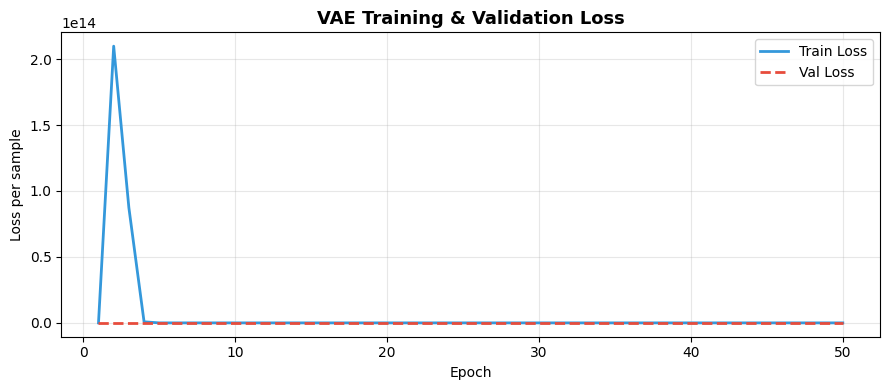

In [25]:
def plot_loss_curves(train_losses, val_losses):
    fig, ax = plt.subplots(figsize=(9, 4))
    epochs_range = range(1, len(train_losses) + 1)

    ax.plot(epochs_range, train_losses, label="Train Loss", linewidth=2, color="#3498db")
    ax.plot(epochs_range, val_losses,   label="Val Loss",   linewidth=2, color="#e74c3c", linestyle="--")
    ax.set_title("VAE Training & Validation Loss", fontsize=13, fontweight="bold")
    ax.set_xlabel("Epoch"); ax.set_ylabel("Loss per sample")
    ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

plot_loss_curves(train_losses, val_losses)


## Section 8 — Latent Space Visualisation & Distribution

In [26]:
def extract_latents(loader, model, device):
    """Return (N, latent_dim) numpy array of μ vectors for the given loader."""
    model.eval()
    latents = []
    with torch.no_grad():
        for x in loader:
            x = x.to(device)
            mu, _ = model.encode(x)
            latents.append(mu.cpu().numpy())
    return np.concatenate(latents, axis=0)

# encode validation (normal) images
val_latents = extract_latents(val_loader, model, device)
print(f"Latent matrix shape: {val_latents.shape}")


Latent matrix shape: (256, 64)


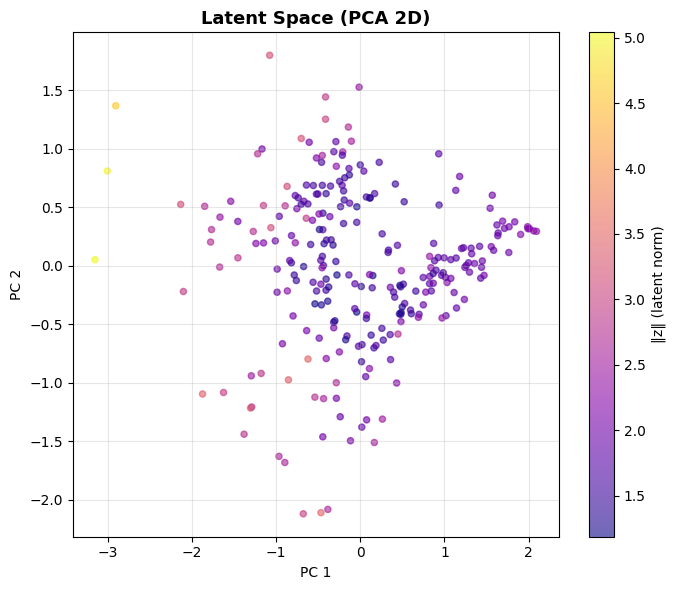

Explained variance: PC1=21.5%, PC2=10.4%


In [27]:
def plot_latent_pca(latents, title="Latent Space (PCA 2D)"):
    pca      = PCA(n_components=2)
    latent2d = pca.fit_transform(latents)

    fig, ax = plt.subplots(figsize=(7, 6))
    sc = ax.scatter(latent2d[:, 0], latent2d[:, 1],
                    c=np.linalg.norm(latents, axis=1),
                    cmap="plasma", alpha=0.6, s=20)
    plt.colorbar(sc, ax=ax, label="‖z‖ (latent norm)")
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_xlabel("PC 1"); ax.set_ylabel("PC 2")
    ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()
    print(f"Explained variance: PC1={pca.explained_variance_ratio_[0]:.1%}, "
          f"PC2={pca.explained_variance_ratio_[1]:.1%}")

plot_latent_pca(val_latents)


### 8b — Latent Distribution Histogram

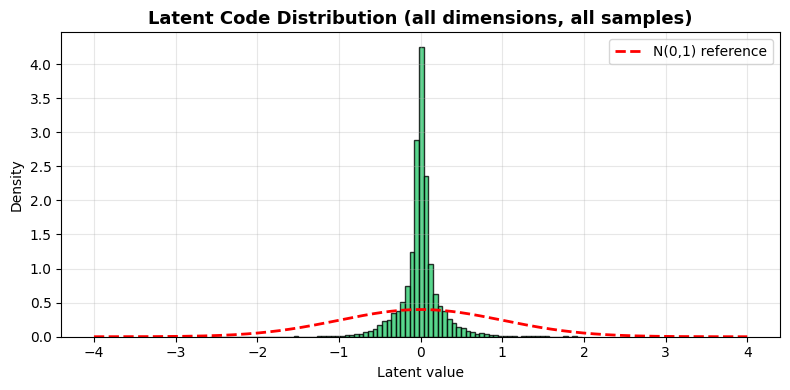

In [28]:
def plot_latent_histogram(latents):
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(latents.flatten(), bins=80, color="#2ecc71", edgecolor="black", alpha=0.8, density=True)

    # overlay N(0,1) reference
    xs = np.linspace(-4, 4, 300)
    from scipy.stats import norm
    ax.plot(xs, norm.pdf(xs), "r--", linewidth=2, label="N(0,1) reference")

    ax.set_title("Latent Code Distribution (all dimensions, all samples)", fontsize=13, fontweight="bold")
    ax.set_xlabel("Latent value"); ax.set_ylabel("Density")
    ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

plot_latent_histogram(val_latents)


## Section 9 — ROI Extraction

In [29]:
def get_roi(diff: np.ndarray,
            blur_ksize: int = 9,
            percentile: float = 97,
            morph_iters: int = 3) -> np.ndarray:
    """
    Convert a per-pixel absolute-difference map to a clean binary ROI mask.

    Parameters
    ----------
    diff        : H×W float array, values in [0, 1]
    blur_ksize  : Gaussian kernel size (must be odd)
    percentile  : threshold percentile (lower = more inclusive)
    morph_iters : morphological close/open iterations

    Returns
    -------
    roi : H×W boolean mask
    """
    # 1. Gaussian blur
    blurred = cv2.GaussianBlur(diff, (blur_ksize, blur_ksize), 0)

    # 2. Percentile threshold
    thresh  = np.percentile(blurred, percentile)
    binary  = (blurred > thresh).astype(np.uint8)

    # 3. Morphological close → fill holes; open → remove specks
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    closed = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel, iterations=morph_iters)
    opened = cv2.morphologyEx(closed, cv2.MORPH_OPEN,  kernel, iterations=morph_iters)

    # 4. Largest connected component
    labeled, n_comp = scipy_label(opened)
    if n_comp == 0:
        return opened.astype(bool)
    sizes   = [(labeled == i).sum() for i in range(1, n_comp + 1)]
    largest = np.argmax(sizes) + 1
    return (labeled == largest).astype(bool)


def dice_score(pred: np.ndarray, gt: np.ndarray) -> float:
    """Sørensen–Dice coefficient between two binary masks."""
    pred, gt     = pred.astype(bool), gt.astype(bool)
    intersection = (pred & gt).sum()
    denom        = pred.sum() + gt.sum()
    return float(2 * intersection / denom) if denom > 0 else 1.0


def load_mask(img_path: str, size: int = 128) -> np.ndarray:
    """Load the paired ground-truth mask for a given image path."""
    mask_path = img_path.replace(".tif", "_mask.tif")
    mask = cv2.imread(mask_path, 0)
    mask = cv2.resize(mask, (size, size))
    return (mask > 0).astype(np.uint8)


## Section 10 — Multi-Sample Inference Visualisation

In [30]:
# Load the best model before inference
model.load_state_dict(torch.load(SAVE_PATH, map_location=device))
model.eval()
print("Best model loaded for inference.")


Best model loaded for inference.


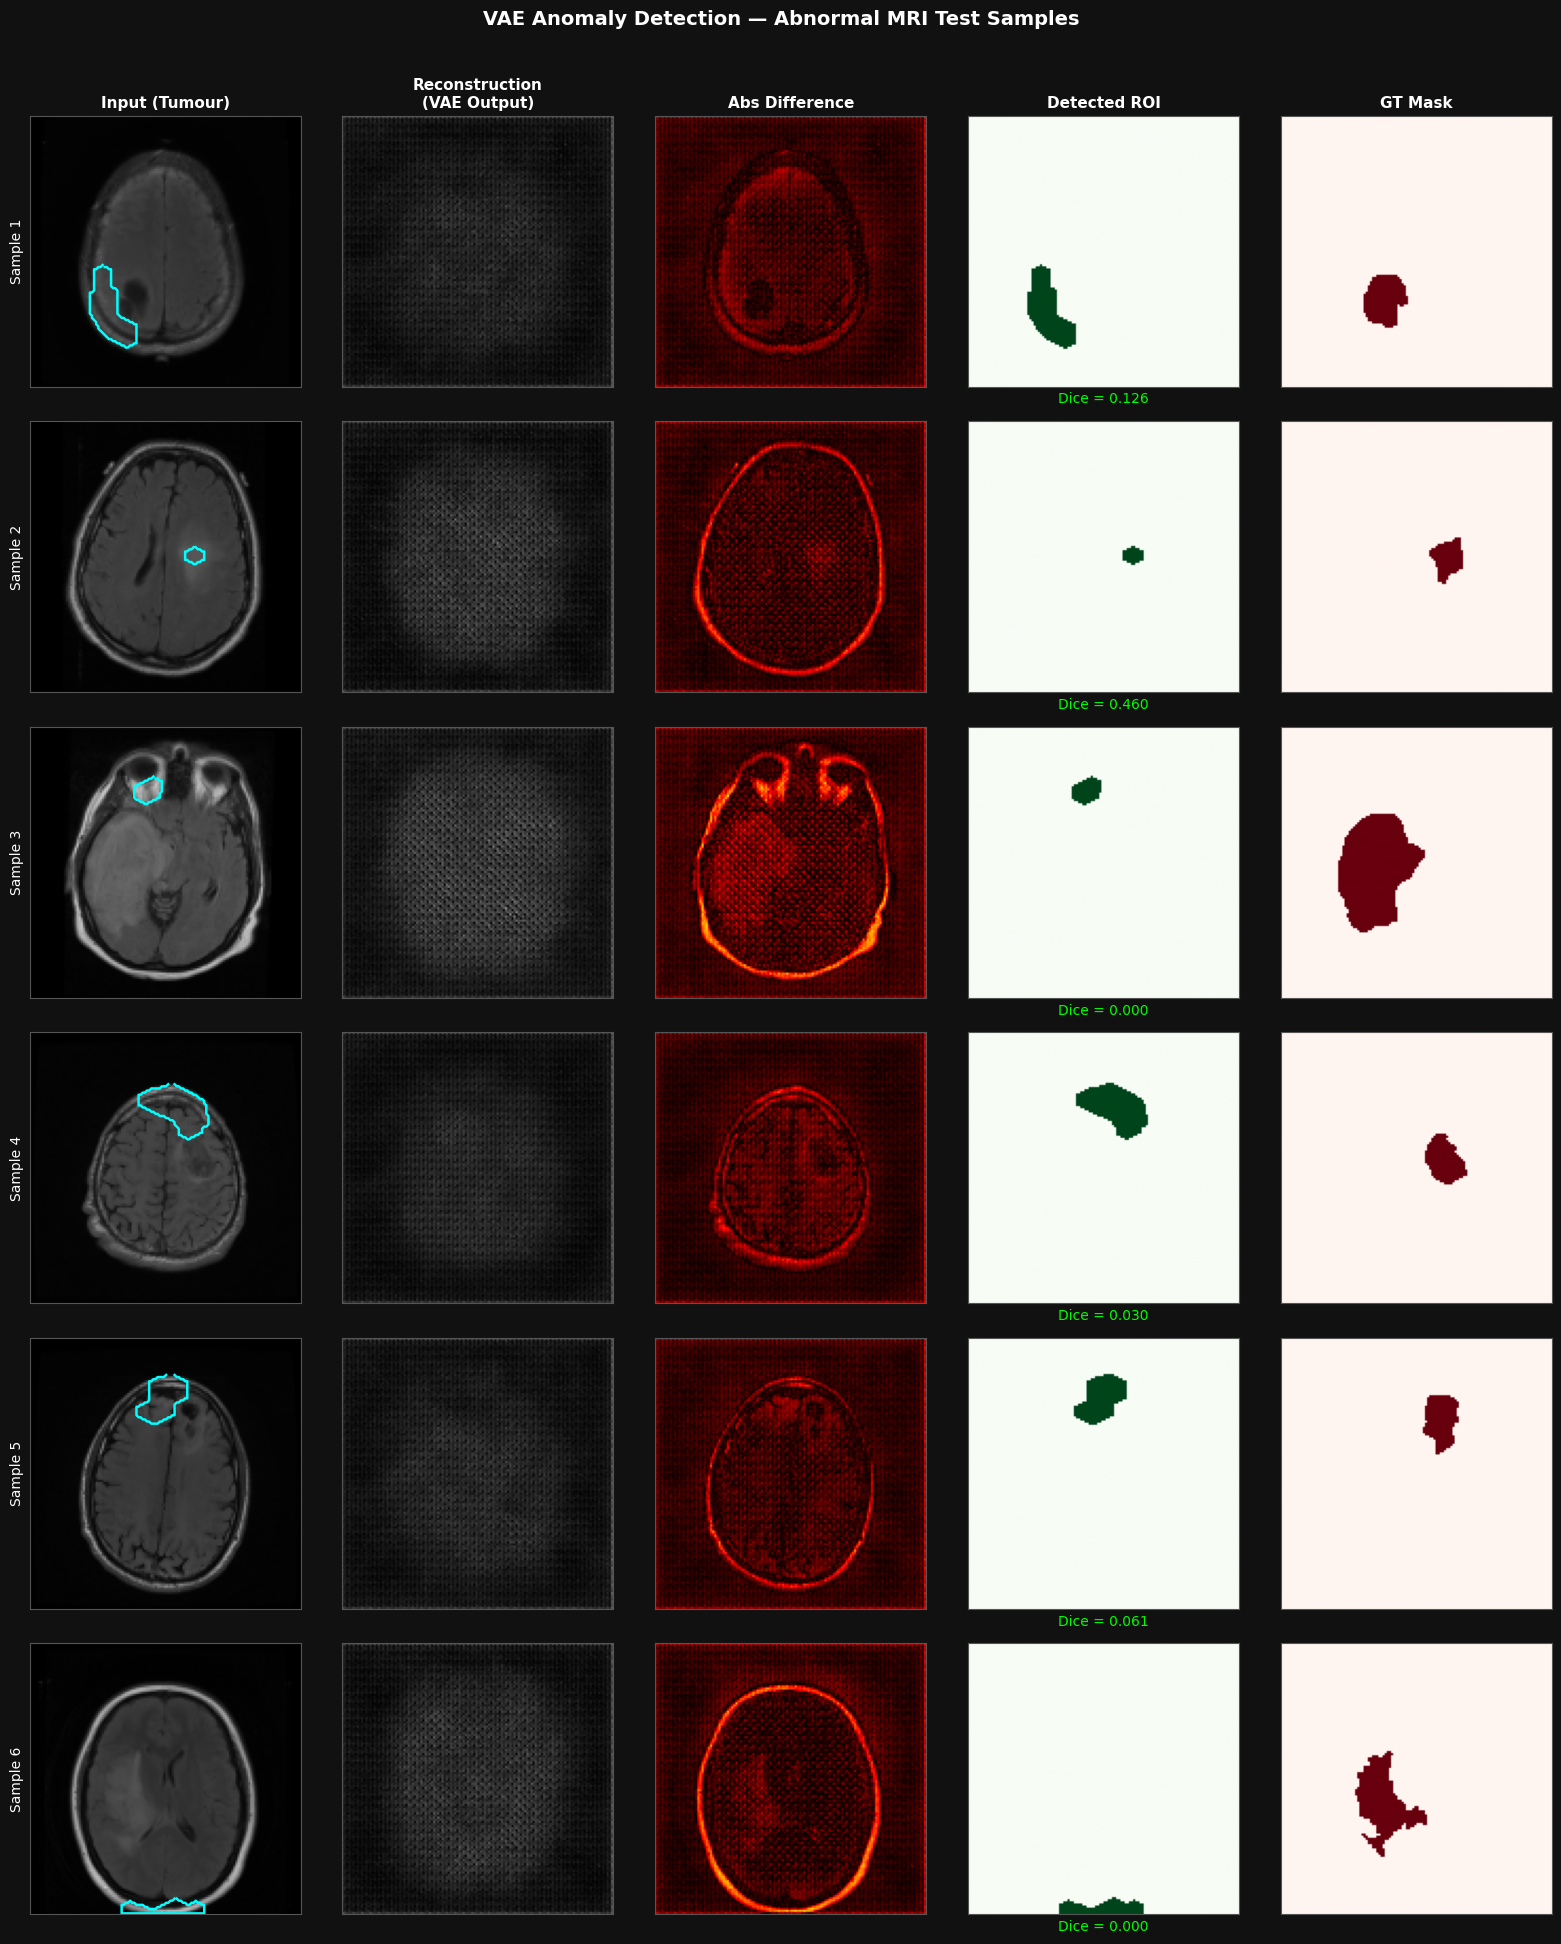

Grid saved → vae_sample_grid.png


In [ ]:
def visualize_vae_samples(model, test_imgs, device,
                          n_samples=6, img_size=128, seed=42):
    """
    Display a grid of (n_samples) rows × 5 columns:
        Input | Reconstruction | Abs Diff | ROI | GT Mask

    Parameters
    ----------
    model      : trained VAE (on `device`)
    test_imgs  : list of abnormal image file paths
    device     : torch.device
    n_samples  : number of sample rows
    img_size   : spatial resolution used during training
    seed       : random seed for reproducible sample selection
    """
    np.random.seed(seed)
    indices   = np.random.choice(len(test_imgs), n_samples, replace=False)
    col_titles = ["Input (Tumour)", "Reconstruction\n(VAE Output)",
                  "Abs Difference", "Detected ROI", "GT Mask"]

    fig, axes = plt.subplots(n_samples, 5, figsize=(5 * 3.2, n_samples * 3.2))
    fig.patch.set_facecolor("#111111")

    for c, title in enumerate(col_titles):
        axes[0, c].set_title(title, color="white", fontsize=11, pad=6, fontweight="bold")

    model.eval()

    for row, idx in enumerate(indices):
        img_path = test_imgs[idx]

        # load
        img_raw = cv2.resize(cv2.imread(img_path, 0), (img_size, img_size)) / 255.0
        gt_mask = load_mask(img_path, img_size)

        x_t = torch.tensor(img_raw[None, None, ...], dtype=torch.float32).to(device)

        # forward
        with torch.no_grad():
            recon, _, _ = model(x_t)
        recon_np = recon.cpu().squeeze().numpy()

        # anomaly map & ROI
        diff = np.abs(img_raw - recon_np)
        roi  = get_roi(diff)
        dice = dice_score(roi, gt_mask)

        # draw
        panels = [(img_raw, "gray"), (recon_np, "gray"),
                  (diff,    "hot"),  (roi,       "Greens"),
                  (gt_mask, "Reds")]

        for col, (im, cmap) in enumerate(panels):
            ax = axes[row, col]
            ax.imshow(im, cmap=cmap, vmin=0, vmax=1 if col < 3 else None)
            ax.set_xticks([]); ax.set_yticks([])
            for spine in ax.spines.values():
                spine.set_edgecolor("#555")

            # overlay ROI contour on the input image
            if col == 0:
                cnts, _ = cv2.findContours(roi.astype(np.uint8),
                                           cv2.RETR_EXTERNAL,
                                           cv2.CHAIN_APPROX_SIMPLE)
                for cnt in cnts:
                    pts = cnt[:, 0, :]
                    ax.plot(pts[:, 0], pts[:, 1], color="cyan", linewidth=1.8)

            if col == 3:
                ax.set_xlabel(f"Dice = {dice:.3f}", color="lime", fontsize=10)

        axes[row, 0].set_ylabel(f"Sample {row + 1}", color="white", fontsize=10)

    plt.suptitle("VAE Anomaly Detection — Abnormal MRI Test Samples",
                 color="white", fontsize=14, y=1.01, fontweight="bold")
    plt.tight_layout()
    plt.savefig("vae_sample_grid.png", dpi=150,
                bbox_inches="tight", facecolor=fig.get_facecolor())
    plt.show()
    print("Grid saved → vae_sample_grid.png")


visualize_vae_samples(model, test_imgs, device, n_samples=6)


## Section 11 — Reconstruction Error Distribution

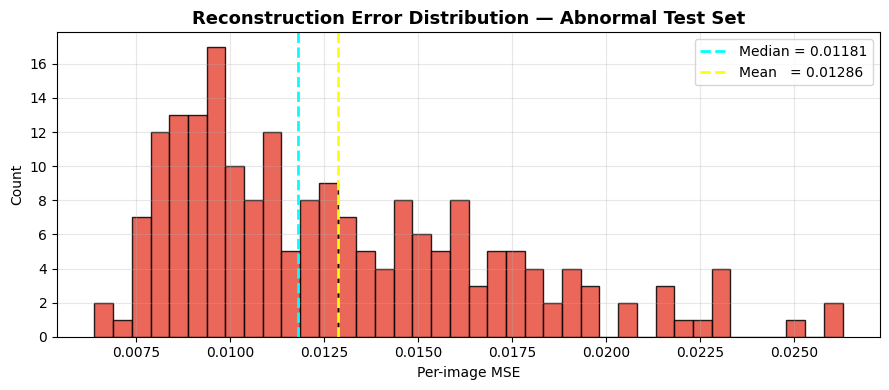

Min  error : 0.006390
Max  error : 0.026281
Mean error : 0.012860
Median     : 0.011814


In [32]:
def plot_reconstruction_error_distribution(model, test_loader, device):
    """Histogram of per-image MSE reconstruction errors on the test set."""
    model.eval()
    errors = []

    with torch.no_grad():
        for x in test_loader:
            x    = x.to(device)
            recon, _, _ = model(x)
            mse  = F.mse_loss(recon, x, reduction="none")
            mse  = mse.mean(dim=[1, 2, 3]).cpu().numpy()
            errors.extend(mse.tolist())

    errors = np.array(errors)
    median_err = np.median(errors)
    mean_err   = np.mean(errors)

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.hist(errors, bins=40, color="#e74c3c", edgecolor="black", alpha=0.85)
    ax.axvline(median_err, color="cyan",   linestyle="--", linewidth=2,
               label=f"Median = {median_err:.5f}")
    ax.axvline(mean_err,   color="yellow", linestyle="--", linewidth=2,
               label=f"Mean   = {mean_err:.5f}")
    ax.set_title("Reconstruction Error Distribution — Abnormal Test Set",
                 fontsize=13, fontweight="bold")
    ax.set_xlabel("Per-image MSE"); ax.set_ylabel("Count")
    ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

    print(f"Min  error : {errors.min():.6f}")
    print(f"Max  error : {errors.max():.6f}")
    print(f"Mean error : {mean_err:.6f}")
    print(f"Median     : {median_err:.6f}")
    return errors

test_errors = plot_reconstruction_error_distribution(model, test_loader, device)


## Section 12 — ROI Quality Analysis

In [33]:
def roi_analysis_single(roi: np.ndarray) -> dict:
    """Compute ROI quality metrics for one binary mask."""
    edge_pixels = int(np.sum(
        cv2.Canny((roi * 255).astype(np.uint8), 50, 150) > 0
    ))
    smoothness  = float(np.var(roi))
    noise_ratio = float(roi.sum() / roi.size)
    return {"edge_pixels": edge_pixels,
            "smoothness":  smoothness,
            "noise_ratio": noise_ratio}


def roi_analysis_table(model, test_imgs, device, n_samples=10, img_size=128, seed=99):
    """Build a summary DataFrame of ROI metrics for n_samples test images."""
    np.random.seed(seed)
    indices = np.random.choice(len(test_imgs), n_samples, replace=False)
    model.eval()
    rows = []

    for idx in indices:
        img_path = test_imgs[idx]
        img_raw  = cv2.resize(cv2.imread(img_path, 0), (img_size, img_size)) / 255.0
        gt_mask  = load_mask(img_path, img_size)

        x_t = torch.tensor(img_raw[None, None, ...], dtype=torch.float32).to(device)
        with torch.no_grad():
            recon, _, _ = model(x_t)
        diff = np.abs(img_raw - recon.cpu().squeeze().numpy())
        roi  = get_roi(diff)

        metrics = roi_analysis_single(roi)
        metrics["dice"]   = round(dice_score(roi, gt_mask), 3)
        metrics["sample"] = os.path.basename(img_path)[:35]
        rows.append(metrics)

    df = pd.DataFrame(rows)[["sample", "smoothness", "edge_pixels", "noise_ratio", "dice"]]
    df = df.sort_values("dice", ascending=False).reset_index(drop=True)
    return df


roi_df = roi_analysis_table(model, test_imgs, device, n_samples=10)
print("\nROI Quality Analysis Table")
print("=" * 75)
print(roi_df.to_string(index=False))



ROI Quality Analysis Table
                      sample  smoothness  edge_pixels  noise_ratio  dice
TCGA_CS_6665_20010817_17.tif    0.051425          116     0.054382 0.658
 TCGA_CS_5393_19990606_7.tif    0.028036          100     0.028870 0.214
TCGA_DU_5849_19950405_25.tif    0.024108           90     0.024719 0.000
TCGA_DU_5851_19950428_13.tif    0.025961           80     0.026672 0.000
TCGA_DU_5871_19941206_24.tif    0.015381           56     0.015625 0.000
TCGA_CS_6188_20010812_15.tif    0.013307           58     0.013489 0.000
TCGA_CS_6669_20020102_10.tif    0.008112           39     0.008179 0.000
TCGA_CS_6669_20020102_18.tif    0.006127           34     0.006165 0.000
TCGA_DU_5849_19950405_24.tif    0.028955           88     0.029846 0.000
TCGA_DU_5871_19941206_20.tif    0.000000            0     0.000000 0.000


### ROI Metrics — Bar Chart Summar

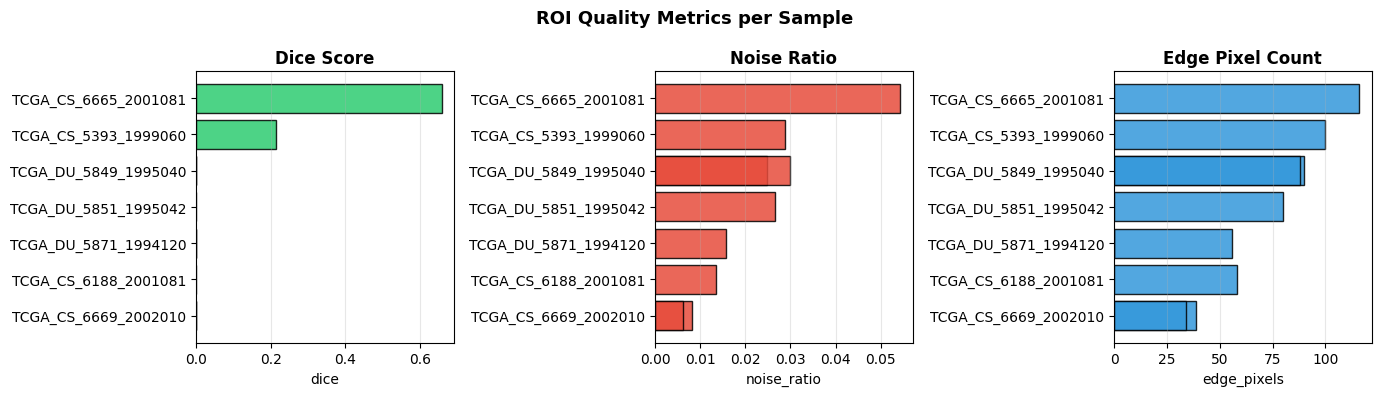

In [34]:
def plot_roi_metrics(roi_df: pd.DataFrame):
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    metrics = [("dice",        "Dice Score",       "#2ecc71"),
               ("noise_ratio", "Noise Ratio",       "#e74c3c"),
               ("edge_pixels", "Edge Pixel Count",  "#3498db")]

    labels = [s[:20] for s in roi_df["sample"]]

    for ax, (col, title, color) in zip(axes, metrics):
        ax.barh(labels, roi_df[col], color=color, edgecolor="black", alpha=0.85)
        ax.set_title(title, fontweight="bold")
        ax.set_xlabel(col)
        ax.grid(axis="x", alpha=0.3)
        ax.invert_yaxis()

    plt.suptitle("ROI Quality Metrics per Sample", fontsize=13, fontweight="bold")
    plt.tight_layout(); plt.show()

plot_roi_metrics(roi_df)


## Section 13 — Conclusions & Future Work

### What we achieved

| Step | Result |
|------|--------|
| Train VAE on normal MRI | Model learns the distribution of healthy brain tissue |
| Reconstruct abnormal MRI | VAE generates a "normal" version — tumour region poorly reconstructed |
| Subtraction + ROI pipeline | 4-step pipeline (blur → threshold → morphology → largest component) produces clean masks |
| Evaluation | Dice score vs. ground-truth mask quantifies detection quality without using labels at train time |

### Key design decisions

- **β-VAE (β=4)**: Stronger KL regularisation → more Gaussian latent space → VAE is more "surprised" by anomalies → sharper difference maps.
- **BatchNorm + LeakyReLU in encoder**: Stabilises training on variable-contrast MRI images.
- **Morphological post-processing**: Dramatically reduces false positives compared to a raw percentile threshold.
- **Largest connected component**: Ensures we return one coherent region rather than scattered noise.

### Limitations

- The VAE blurs globally, not just on tumours — some false positives near high-frequency anatomy (skull edges).
- Dice scores are variable depending on tumour size and contrast.
- Only 200 abnormal test images used; using all improves statistical robustness.

### Possible Improvements

1. **Larger latent dim** (128–256) with more encoder depth for finer reconstruction.
2. **Perceptual loss** (SSIM or VGG feature matching) to sharpen reconstructions.
3. **Ensemble thresholding** — average multiple stochastic forward passes (MC sampling) for a smoother anomaly map.
4. **Test-time augmentation** — flip/rotate inputs and average difference maps.
5. **Supervised fine-tuning** — use detected ROI as pseudo-labels for a segmentation network.